<a href="https://colab.research.google.com/github/rymarinelli/Advanced-Programming-/blob/main/Norbert_Eval_SEB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q seb sentence-transformers transformers accelerate datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.4/173.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 39.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.9.2 which is incompatible.


In [ ]:
import re
import numpy as np
import torch
import seb
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from transformers import AutoModel, AutoTokenizer, AutoConfig, logging

logging.set_verbosity_error()

# -----------------------------
# Settings
# -----------------------------
MODEL_SPECS = [
    ("norbert4-xsmall-seb", "ltg/norbert4-xsmall", "NorBERT-4 xsmall"),
    ("norbert4-small-seb",  "ltg/norbert4-small",  "NorBERT-4 small"),
    ("norbert4-base-seb",   "ltg/norbert4-base",   "NorBERT-4 base"),
    ("norbert4-large-seb",  "ltg/norbert4-large",  "NorBERT-4 large"),
    ("norbert4-xlarge-seb", "ltg/norbert4-xlarge", "NorBERT-4 xlarge"),
]

TASKS = [
    "NoReC",
    "Norwegian parliament",
    "Norwegian courts",
    "VG Clustering",
    "NorQuad",
]

BATCH_SIZE = 32
MAX_LENGTH = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RAW_SAVE_DIR = Path("seb_raw_results_multi")
RAW_SAVE_DIR.mkdir(exist_ok=True)

# -----------------------------
# Encoder factory
# -----------------------------
def make_encoder_class(model_name: str):
    class NorBERTEncoder(seb.Encoder):
        def __init__(self):
            print(f"Loading {model_name} on {DEVICE}...")
            self.tokenizer = AutoTokenizer.from_pretrained(
                model_name,
                trust_remote_code=True
            )
            self.model = AutoModel.from_pretrained(
                model_name,
                trust_remote_code=True
            )
            self.model.eval()
            self.device = DEVICE
            self.model.to(self.device)

        def mean_pool(self, hidden, mask):
            mask = mask.unsqueeze(-1).expand(hidden.size()).float()
            summed = torch.sum(hidden * mask, dim=1)
            counts = torch.clamp(mask.sum(dim=1), min=1e-9)
            return summed / counts

        def encode(self, sentences: list[str], *, task: seb.Task, **kwargs):
            sentences = [str(s) for s in sentences]
            embeddings = []

            for i in range(0, len(sentences), BATCH_SIZE):
                batch = sentences[i:i + BATCH_SIZE]

                tokens = self.tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=MAX_LENGTH,
                    return_tensors="pt"
                )
                tokens = {k: v.to(self.device) for k, v in tokens.items()}

                with torch.no_grad():
                    outputs = self.model(**tokens)

                # Prefer last_hidden_state if present
                if hasattr(outputs, "last_hidden_state") and outputs.last_hidden_state is not None:
                    hidden = outputs.last_hidden_state
                # Fallback for unusual model outputs
                elif isinstance(outputs, (tuple, list)) and len(outputs) > 0:
                    hidden = outputs[0]
                else:
                    raise ValueError(f"{model_name}: could not find token-level hidden states in model output")

                pooled = self.mean_pool(hidden, tokens["attention_mask"])
                pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
                embeddings.append(pooled.cpu())

            embeddings = torch.cat(embeddings, dim=0)
            embeddings = torch.nan_to_num(
                embeddings,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )
            return embeddings.numpy().astype(np.float32)

    return NorBERTEncoder

# -----------------------------
# Register all models dynamically
# -----------------------------
registered_model_ids = []

for model_id, model_name, pretty_name in MODEL_SPECS:
    config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
    hidden_size = int(config.hidden_size)

    EncoderClass = make_encoder_class(model_name)

    @seb.models.register(model_id)
    def create_model(
        _model_id=model_id,
        _model_name=model_name,
        _pretty_name=pretty_name,
        _hidden_size=hidden_size,
        _EncoderClass=EncoderClass
    ) -> seb.SebModel:
        meta = seb.ModelMeta(
            name=_pretty_name,
            huggingface_name=_model_name,
            languages=["nb"],
            embedding_size=_hidden_size,
        )
        return seb.SebModel(
            encoder=_EncoderClass(),
            meta=meta
        )

    registered_model_ids.append(model_id)

# -----------------------------
# Run benchmark
# -----------------------------
benchmark = seb.Benchmark(tasks=TASKS)
models = [seb.registries.get_model(mid) for mid in registered_model_ids]

print("Starting SEB evaluation...")
results = benchmark.evaluate_models(models, use_cache=False)
print("Evaluation finished.")

# -----------------------------
# Collect results
# -----------------------------
rows = []

for model_idx, model_result in enumerate(results):
    model_name = MODEL_SPECS[model_idx][2]

    # Save raw results if possible
    if hasattr(model_result, "to_disk"):
        safe_name = re.sub(r"[^a-zA-Z0-9_-]+", "_", model_name.lower())
        model_dir = RAW_SAVE_DIR / safe_name
        model_result.to_disk(model_dir)

    if not hasattr(model_result, "task_results"):
        continue

    for task_result in model_result.task_results:
        if not hasattr(task_result, "scores") or not hasattr(task_result, "main_score"):
            continue

        main_metric = task_result.main_score
        task_name = getattr(task_result, "task_name", "unknown_task")

        for lang, score_dict in task_result.scores.items():
            if main_metric not in score_dict:
                continue

            score_value = score_dict[main_metric]

            if isinstance(score_value, (int, float, np.integer, np.floating)):
                rows.append({
                    "model": model_name,
                    "task": task_name,
                    "language": lang,
                    "metric": main_metric,
                    "score": float(score_value),
                })

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError("No SEB results were collected.")

print("\nCollected results:")
print(df)

df.to_csv("seb_results_multi.csv", index=False)
print("\nSaved CSV to seb_results_multi.csv")
print(f"Saved raw result bundles to {RAW_SAVE_DIR.resolve()}")

# -----------------------------
# Aggregate over languages
# -----------------------------
plot_df = (
    df.groupby(["task", "model"], as_index=False)["score"]
    .mean()
)

pivot_df = plot_df.pivot(index="model", columns="task", values="score")
print("\nMean score per model per task:")
print(pivot_df)

pivot_df.to_csv("seb_results_task_level_comparison.csv")
print("Saved task-level comparison CSV to seb_results_task_level_comparison.csv")


config.json: 0.00B [00:00, ?B/s]

configuration_gptbert.py: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_gptbert.py: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Generating train split:   0%|          | 0/1024 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/256 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2048 [00:00<?, ? examples/s]


Running NorBERT-4 small on Norwegian courts:  40%|████      | 2/5 [00:13<00:20,  6.72s/it]    /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

Running NorBERT-4 small on VG Clustering:  60%|██████    | 3/5 [00:13<00:07,  3.76s/it]   

Clustering:   0%|          | 0/4 [00:00<?, ?it/s]

Clustering:  25%|██▌       | 1/4 [00:00<00:02,  1.09it/s]

Clustering:  50%|█████     | 2/4 [00:01<00:01,  1.07it/s]

Clustering:  75%|███████▌  | 3/4 [00:02<00:00,  1.08it/s]

Clustering: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]

Running NorBERT-4 base on Norwegian courts:  40%|████      | 2/5 [00:12<00:18,  6.26s/it]    /usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision 

Evaluation finished.

Collected results:
               model                  task language      metric     score
0   NorBERT-4 xsmall                 NoReC       nb    accuracy  0.163574
1   NorBERT-4 xsmall  Norwegian parliament       nb    accuracy  0.500000
2   NorBERT-4 xsmall      Norwegian courts       nb          f1  0.000038
3   NorBERT-4 xsmall      Norwegian courts       nn          f1  0.000038
4   NorBERT-4 xsmall         VG Clustering       nb   v_measure  0.000000
5   NorBERT-4 xsmall               NorQuad       nb  ndcg_at_10  0.003710
6    NorBERT-4 small                 NoReC       nb    accuracy  0.337939
7    NorBERT-4 small  Norwegian parliament       nb    accuracy  0.511917
8    NorBERT-4 small      Norwegian courts       nb          f1  0.401754
9    NorBERT-4 small      Norwegian courts       nn          f1  0.401754
10   NorBERT-4 small         VG Clustering       nb   v_measure  0.049994
11   NorBERT-4 small               NorQuad       nb  ndcg_at_10  0.0062

# Plotting

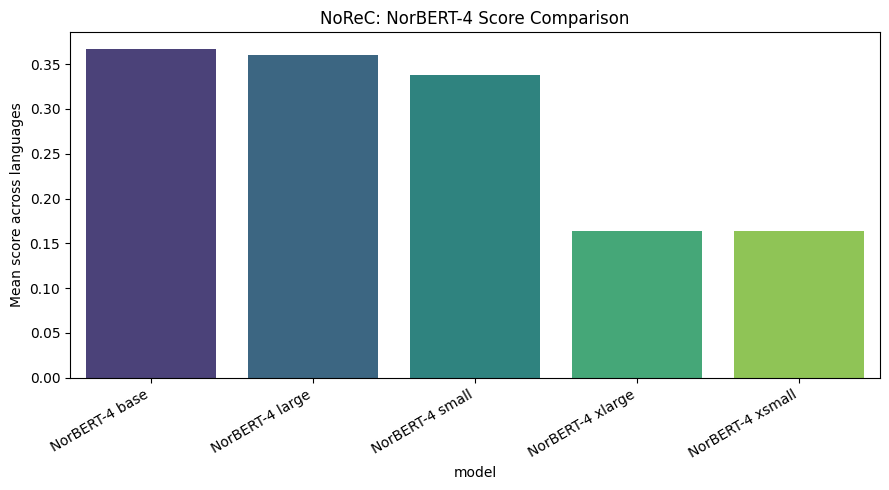

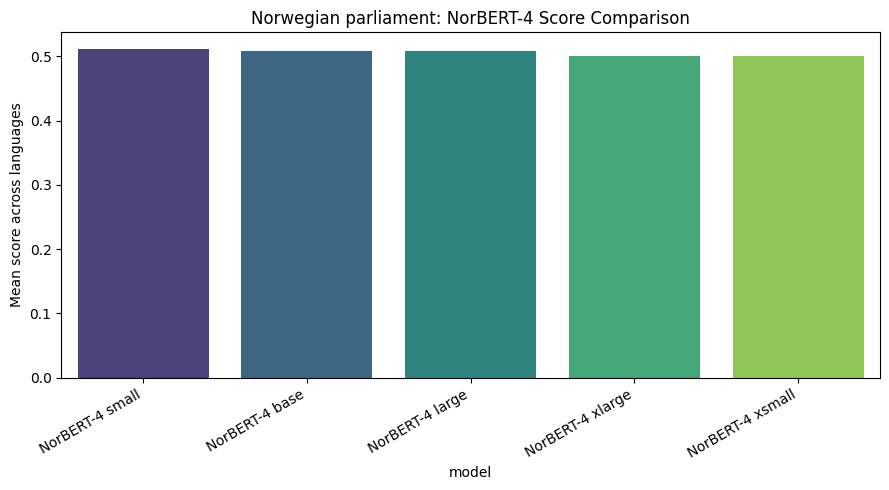

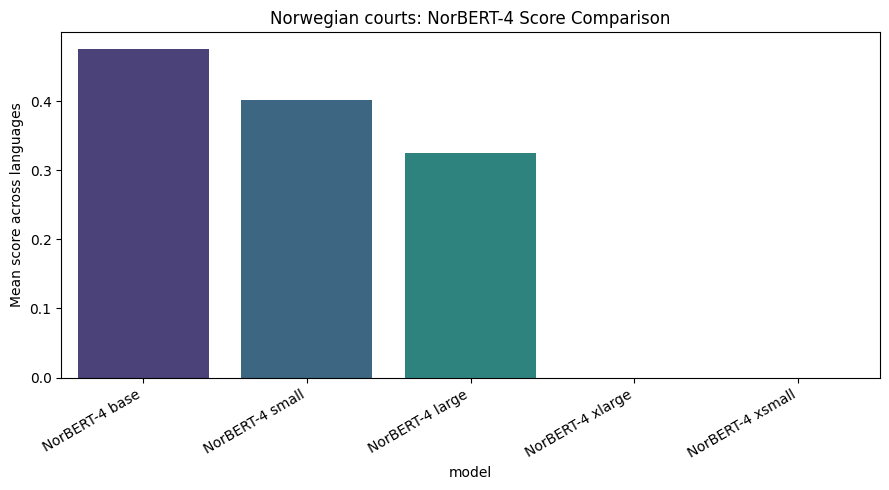

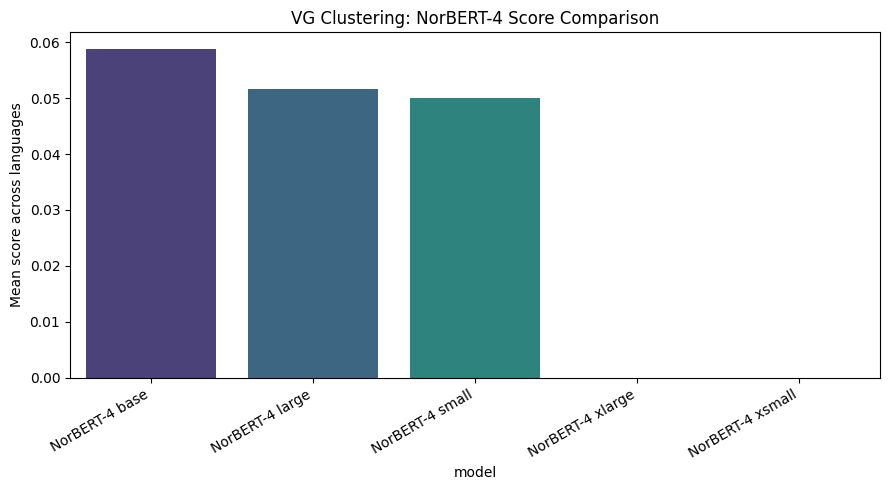

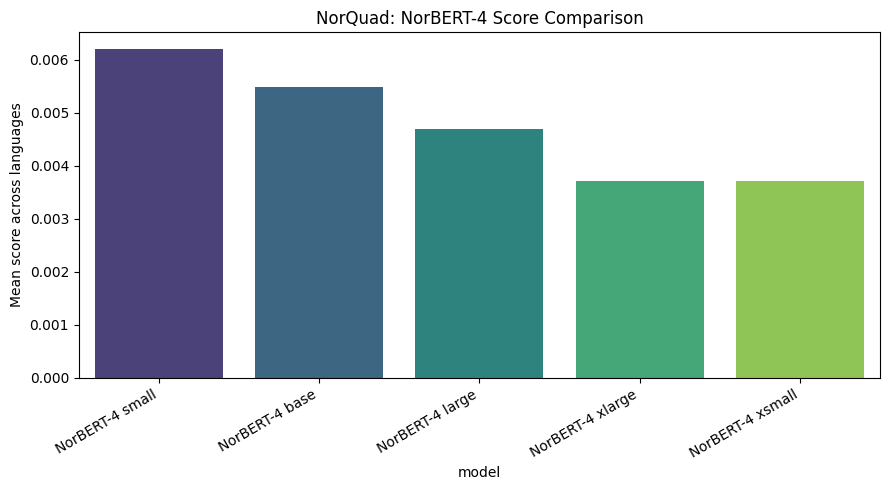

In [ ]:
import seaborn as sns

# -----------------------------
# One plot per task
# -----------------------------
for task in TASKS:
    task_df = plot_df[plot_df["task"] == task].copy()

    if task_df.empty:
        print(f"Skipping plot for {task} because no data was found.")
        continue

    task_df = task_df.sort_values("score", ascending=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(x=task_df["model"], y=task_df["score"], hue=task_df["model"], palette='viridis', legend=False)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Mean score across languages")
    plt.title(f"{task}: NorBERT-4 Score Comparison")
    plt.tight_layout()

    safe_task = re.sub(r"[^a-zA-Z0-9_-]+", "_", task.lower())
    plt.savefig(f"{safe_task}_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

In [ ]:
#  hidden sizes for NorBERT models
model_hidden_sizes = {
    "NorBERT-4 xsmall": 256,
    "NorBERT-4 small": 384,
    "NorBERT-4 base": 640,
    "NorBERT-4 large": 1024,
    "NorBERT-4 xlarge": 1536,
}

# Add hidden size column
plot_df_with_size = plot_df.copy()
plot_df_with_size["hidden_size"] = plot_df_with_size["model"].map(model_hidden_sizes)

# Now your ratio code works
ratio_df = plot_df_with_size.copy()

ratio_df["param_size_to_score_ratio"] = (
    ratio_df["hidden_size"] / ratio_df["score"]
)

ratio_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("DataFrame with parameter size to score ratio:")
display(ratio_df)

DataFrame with parameter size to score ratio:


,task,model,score,hidden_size,param_size_to_score_ratio
0,NoReC,NorBERT-4 base,0.367285,640,1.742515e+03
1,NoReC,NorBERT-4 large,0.359863,1024,2.845525e+03
2,NoReC,NorBERT-4 small,0.337939,384,1.136298e+03
3,NoReC,NorBERT-4 xlarge,0.163574,1536,9.390233e+03
4,NoReC,NorBERT-4 xsmall,0.163574,256,1.565039e+03
5,NorQuad,NorBERT-4 base,0.005490,640,1.165756e+05
6,NorQuad,NorBERT-4 large,0.004700,1024,2.178723e+05
7,NorQuad,NorBERT-4 small,0.006210,384,6.183575e+04
8,NorQuad,NorBERT-4 xlarge,0.003710,1536,4.140162e+05
9,NorQuad,NorBERT-4 xsmall,0.003710,256,6.900270e+04


In [ ]:
import numpy as np

# Create a copy to avoid modifying the original DataFrame
ratio_df = plot_df_with_size.copy()

# Calculate the ratio of hidden_size to score
# Handle cases where score is 0 to avoid division by zero (resulting in inf)
ratio_df['param_size_to_score_ratio'] = ratio_df['hidden_size'] / ratio_df['score']

# Replace inf values (from division by zero) with NaN for better plotting
ratio_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("DataFrame with parameter size to score ratio (NaN indicates a score of 0):")
display(ratio_df)


DataFrame with parameter size to score ratio (NaN indicates a score of 0):


,task,model,score,hidden_size,param_size_to_score_ratio
0,NoReC,NorBERT-4 base,0.367285,640,1.742515e+03
1,NoReC,NorBERT-4 large,0.359863,1024,2.845525e+03
2,NoReC,NorBERT-4 small,0.337939,384,1.136298e+03
3,NoReC,NorBERT-4 xlarge,0.163574,1536,9.390233e+03
4,NoReC,NorBERT-4 xsmall,0.163574,256,1.565039e+03
5,NorQuad,NorBERT-4 base,0.005490,640,1.165756e+05
6,NorQuad,NorBERT-4 large,0.004700,1024,2.178723e+05
7,NorQuad,NorBERT-4 small,0.006210,384,6.183575e+04
8,NorQuad,NorBERT-4 xlarge,0.003710,1536,4.140162e+05
9,NorQuad,NorBERT-4 xsmall,0.003710,256,6.900270e+04


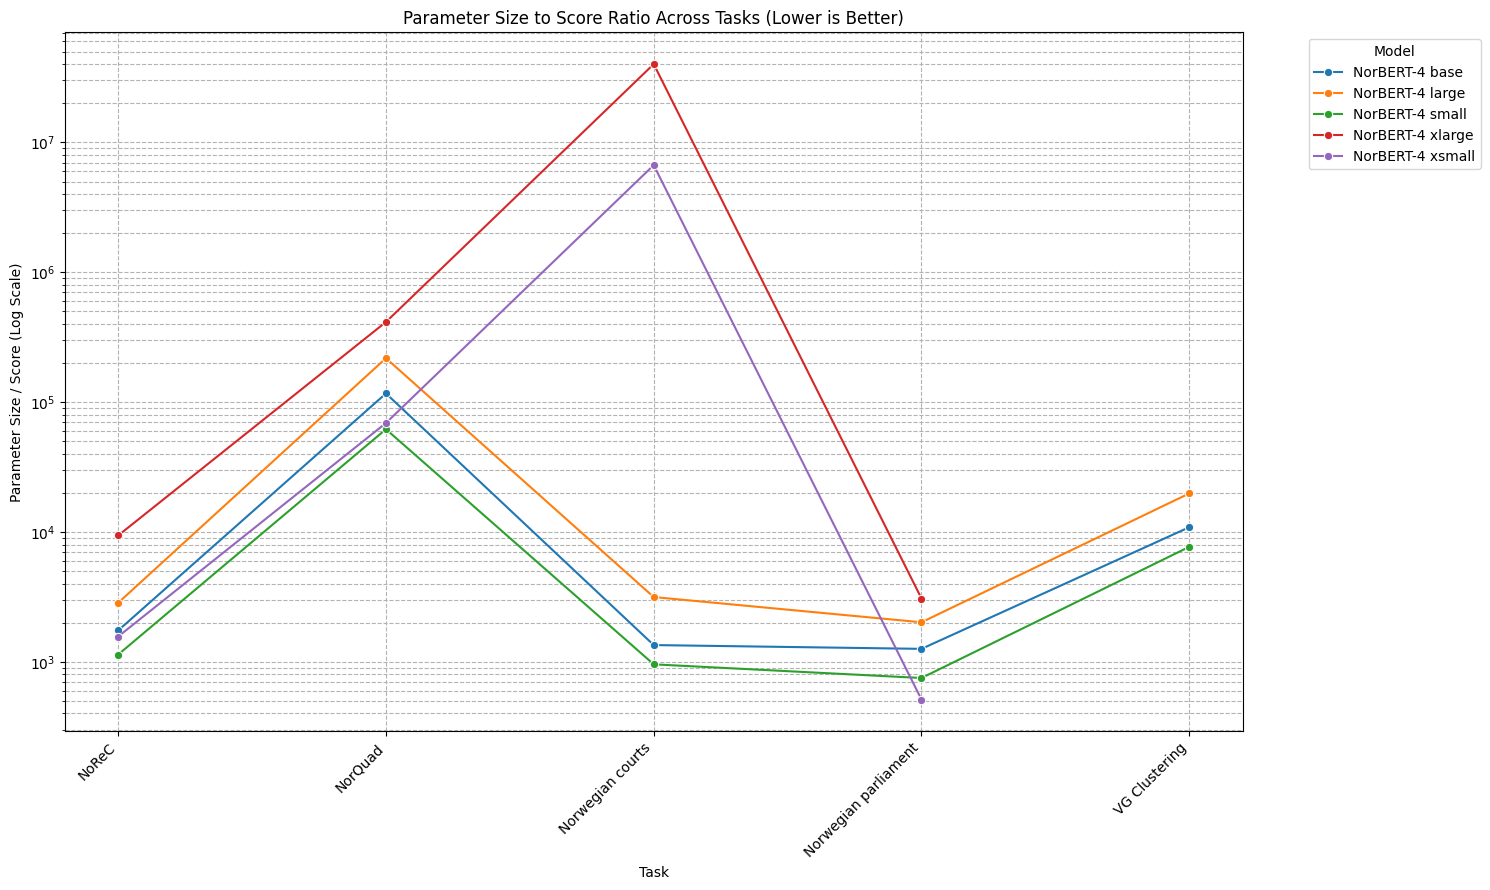

In [ ]:
plt.figure(figsize=(15, 9))

sns.lineplot(data=ratio_df, x="task", y="param_size_to_score_ratio", hue="model", marker="o")
plt.yscale('log') # Use a log scale for y-axis if ratios vary widely
plt.title("Parameter Size to Score Ratio Across Tasks (Lower is Better)")
plt.xlabel("Task")
plt.ylabel("Parameter Size / Score (Log Scale)")
plt.xticks(rotation=45, ha='right')
plt.grid(True, which="both", ls="--", c="0.7")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()